# Exploration des données

## Introduction

Ce notebook constitue la première étape de l'analyse du projet **Trafic cycliste à Paris**. Il explore les données brutes de comptage des vélos à Paris avant toute transformation.

### Jeu de données

Le dataset utilisé est `comptage-velo-donnees-compteurs.csv`, une source open data de la Ville de Paris recensant les comptages horaires de vélos sur l'ensemble du réseau de pistes cyclables. Il contient **947 043 lignes** et **16 colonnes**, couvrant la période de **mai 2024 à juin 2025**, avec des relevés provenant de **108 compteurs répartis sur 66 sites**.

### Objectif

L'objectif de ce notebook est de :
- Comprendre la structure et le contenu du dataset
- Identifier les valeurs manquantes, les doublons et les valeurs aberrantes
- Analyser la couverture temporelle par compteur
- Formuler des recommandations de nettoyage pour les étapes suivantes (preprocessing, modélisation)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Importation des données brutes
df = pd.read_csv('../data/raw/comptage-velo-donnees-compteurs.csv', sep=';')

In [3]:
df.head()

,Identifiant du compteur,Nom du compteur,Identifiant du site de comptage,Nom du site de comptage,Comptage horaire,Date et heure de comptage,Date d'installation du site de comptage,Lien vers photo du site de comptage,Coordonnées géographiques,Identifiant technique compteur,ID Photos,test_lien_vers_photos_du_site_de_comptage_,id_photo_1,url_sites,type_dimage,mois_annee_comptage
0,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T05:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
1,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T09:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
2,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T08:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
3,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T06:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
4,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T14:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947043 entries, 0 to 947042
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Identifiant du compteur                     913901 non-null  object 
 1   Nom du compteur                             947043 non-null  object 
 2   Identifiant du site de comptage             913901 non-null  float64
 3   Nom du site de comptage                     913901 non-null  object 
 4   Comptage horaire                            947043 non-null  int64  
 5   Date et heure de comptage                   947043 non-null  object 
 6   Date d'installation du site de comptage     913901 non-null  object 
 7   Lien vers photo du site de comptage         904072 non-null  object 
 8   Coordonnées géographiques                   913901 non-null  object 
 9   Identifiant technique compteur              904072 non-null  object 
 

Pour plus d'information concernant les colonnes du dataset d'origine, consulter le fichier **Description-colonnes.pdf** dans le dossier reports.

## Analyse des outliers

In [5]:
df.describe()

,Identifiant du site de comptage,Comptage horaire
count,9.139010e+05,947043.000000
mean,1.345572e+08,79.651583
std,7.556569e+07,108.453806
min,1.000031e+08,0.000000
25%,1.000475e+08,11.000000
50%,1.000560e+08,44.000000
75%,1.000563e+08,100.000000
max,3.000303e+08,3070.000000


La colonne 'Identifiant du site de comptage' contient des **valeurs nominales**, pas quantitatives. Transformer le type en str si la colonne est conservée.

On constate une valeur maximale de 3070 dans la colonne 'Comptage horaire'. Valeur aberrante ?

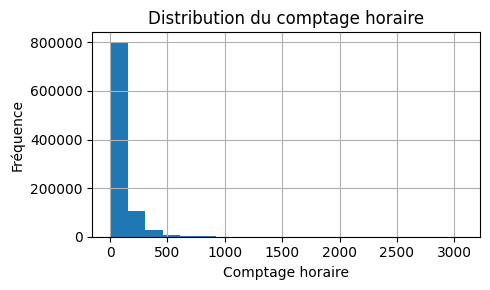

In [6]:
plt.figure(figsize=(5, 3))
df['Comptage horaire'].hist(bins=20)
plt.title("Distribution du comptage horaire")
plt.xlabel("Comptage horaire")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.savefig('../reports/figures/histogram_comptage_horaire.png', dpi=150)
plt.show()

La majorité des valeurs se situent en dessous de 200 passages par heure.

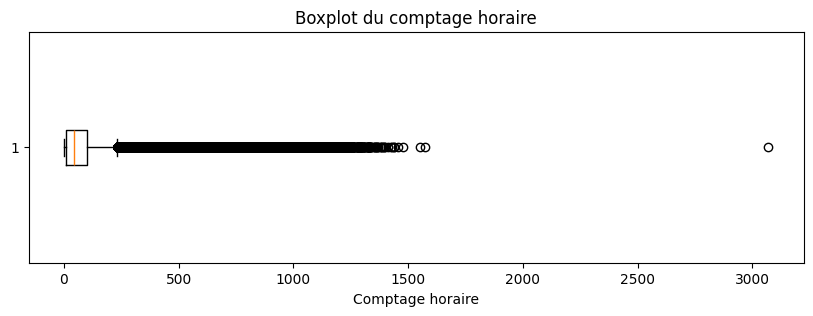

In [ ]:
plt.figure(figsize=(10, 3))
plt.boxplot(df['Comptage horaire'], vert=False)
plt.title("Boxplot du comptage horaire")
plt.xlabel("Comptage horaire")
plt.show()

# Version exploratoire, non sauvegardée

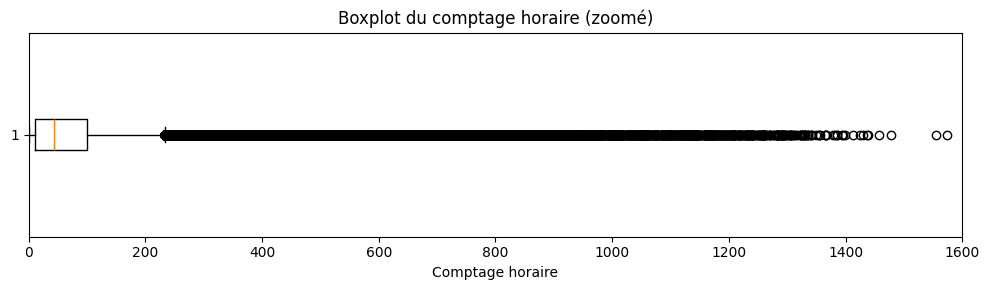

In [8]:
plt.figure(figsize=(10, 3))
plt.boxplot(df['Comptage horaire'], vert=False)
plt.xlim(0, 1600)
plt.title("Boxplot du comptage horaire (zoomé)")
plt.xlabel("Comptage horaire")
plt.tight_layout()
plt.savefig('../reports/figures/boxplot_comptage_horaire.png', dpi=150)
plt.show()

In [9]:
# Calcul de la borne supérieure pour détecter les valeurs aberrantes
Q1 = df['Comptage horaire'].quantile(0.25)
Q3 = df['Comptage horaire'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(upper_bound)

233.5


In [10]:
df_outliers = df[df['Comptage horaire'] > upper_bound]

df_outliers

,Identifiant du compteur,Nom du compteur,Identifiant du site de comptage,Nom du site de comptage,Comptage horaire,Date et heure de comptage,Date d'installation du site de comptage,Lien vers photo du site de comptage,Coordonnées géographiques,Identifiant technique compteur,ID Photos,test_lien_vers_photos_du_site_de_comptage_,id_photo_1,url_sites,type_dimage,mois_annee_comptage
9880,100006300-101006300,135 avenue Daumesnil SE-NO,100006300.0,135 avenue Daumesnil,291,2024-05-06T08:00:00+02:00,2013-01-19,https://filer.eco-counter-tools.com/file/0f/72...,"48.843435,2.383378",X2H18086316,https://filer.eco-counter-tools.com/file/0f/72...,https://filer.eco-counter-tools.com/file/0f/72...,https:,https://www.eco-visio.net/Photos/100006300,jpg,2024-05
9896,100006300-101006300,135 avenue Daumesnil SE-NO,100006300.0,135 avenue Daumesnil,276,2024-05-02T08:00:00+02:00,2013-01-19,https://filer.eco-counter-tools.com/file/0f/72...,"48.843435,2.383378",X2H18086316,https://filer.eco-counter-tools.com/file/0f/72...,https://filer.eco-counter-tools.com/file/0f/72...,https:,https://www.eco-visio.net/Photos/100006300,jpg,2024-05
10013,100006300-101006300,135 avenue Daumesnil SE-NO,100006300.0,135 avenue Daumesnil,263,2024-05-07T08:00:00+02:00,2013-01-19,https://filer.eco-counter-tools.com/file/0f/72...,"48.843435,2.383378",X2H18086316,https://filer.eco-counter-tools.com/file/0f/72...,https://filer.eco-counter-tools.com/file/0f/72...,https:,https://www.eco-visio.net/Photos/100006300,jpg,2024-05
10057,100006300-101006300,135 avenue Daumesnil SE-NO,100006300.0,135 avenue Daumesnil,362,2024-05-13T08:00:00+02:00,2013-01-19,https://filer.eco-counter-tools.com/file/0f/72...,"48.843435,2.383378",X2H18086316,https://filer.eco-counter-tools.com/file/0f/72...,https://filer.eco-counter-tools.com/file/0f/72...,https:,https://www.eco-visio.net/Photos/100006300,jpg,2024-05
10101,100006300-101006300,135 avenue Daumesnil SE-NO,100006300.0,135 avenue Daumesnil,258,2024-05-07T09:00:00+02:00,2013-01-19,https://filer.eco-counter-tools.com/file/0f/72...,"48.843435,2.383378",X2H18086316,https://filer.eco-counter-tools.com/file/0f/72...,https://filer.eco-counter-tools.com/file/0f/72...,https:,https://www.eco-visio.net/Photos/100006300,jpg,2024-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946949,300030271-353356061,Face au 49 boulevard du Général Martial Valin ...,300030271.0,Face au 49 boulevard du Général Martial Valin,285,2025-06-04T18:00:00+02:00,2023-02-02,https://filer.eco-counter-tools.com/file/a8/4a...,"48.837055,2.274019",Y2H22115088,https://filer.eco-counter-tools.com/file/a8/4a...,https://filer.eco-counter-tools.com/file/a8/4a...,https:,https://www.eco-visio.net/Photos/300030271,jpg,2025-06
946993,300030271-353356061,Face au 49 boulevard du Général Martial Valin ...,300030271.0,Face au 49 boulevard du Général Martial Valin,331,2025-06-10T08:00:00+02:00,2023-02-02,https://filer.eco-counter-tools.com/file/a8/4a...,"48.837055,2.274019",Y2H22115088,https://filer.eco-counter-tools.com/file/a8/4a...,https://filer.eco-counter-tools.com/file/a8/4a...,https:,https://www.eco-visio.net/Photos/300030271,jpg,2025-06
947004,300030271-353356061,Face au 49 boulevard du Général Martial Valin ...,300030271.0,Face au 49 boulevard du Général Martial Valin,339,2025-06-11T08:00:00+02:00,2023-02-02,https://filer.eco-counter-tools.com/file/a8/4a...,"48.837055,2.274019",Y2H22115088,https://filer.eco-counter-tools.com/file/a8/4a...,https://filer.eco-counter-tools.com/file/a8/4a...,https:,https://www.eco-visio.net/Photos/300030271,jpg,2025-06
947005,300030271-353356061,Face au 49 boulevard du Général Martial Valin ...,300030271.0,Face au 49 boulevard du Général Martial Valin,236,2025-06-11T09:00:00+02:00,2023-02-02,https://filer.eco-counter-tools.com/file/a8/4a...,"48.837055,2.274019",Y2H22115088,https://filer.eco-counter-tools.com/file/a8/4a...,https://filer.eco-counter-tools.com/file/a8/4a...,https:,https://www.eco-visio.net/Photos/300030271,jpg,2025-06


In [11]:
print("Nombre d'outliers :", len(df_outliers))
pourcentage = round(len(df_outliers) / len(df) * 100, 2)
print(f"Les outliers représentent {pourcentage} % du dataset.")

Nombre d'outliers : 74567
Les outliers représentent 7.87 % du dataset.


In [12]:
len(df[df['Comptage horaire'] > 1500])

3

Statistiquement, plus de 70000 valeurs sont identifiées comme des outliers dans le jeu de données. Ce nombre me paraît trop élevé pour qu’il s’agisse uniquement de valeurs réellement aberrantes. D’après le dernier boxplot présenté ci-dessus, le seuil semble plutôt se situer autour de 1500, ce qui donnerait seulement trois valeurs aberrantes.

## Vérification de doublons

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[df.duplicated(subset=['Nom du compteur', 'Date et heure de comptage'], keep=False)]

,Identifiant du compteur,Nom du compteur,Identifiant du site de comptage,Nom du site de comptage,Comptage horaire,Date et heure de comptage,Date d'installation du site de comptage,Lien vers photo du site de comptage,Coordonnées géographiques,Identifiant technique compteur,ID Photos,test_lien_vers_photos_du_site_de_comptage_,id_photo_1,url_sites,type_dimage,mois_annee_comptage


Le dataset ne contient aucun doublon.

## Valeurs manquantes

In [15]:
# Taux des valeurs manquantes par colonne
round(df.isnull().mean() * 100, 2)

Identifiant du compteur                       3.50
Nom du compteur                               0.00
Identifiant du site de comptage               3.50
Nom du site de comptage                       3.50
Comptage horaire                              0.00
Date et heure de comptage                     0.00
Date d'installation du site de comptage       3.50
Lien vers photo du site de comptage           4.54
Coordonnées géographiques                     3.50
Identifiant technique compteur                4.54
ID Photos                                     4.54
test_lien_vers_photos_du_site_de_comptage_    4.54
id_photo_1                                    4.54
url_sites                                     3.50
type_dimage                                   4.54
mois_annee_comptage                           0.00
dtype: float64

Est-ce que les valeurs manquantes sont distribuées aléatoirement sur les colonnes affichant le même taux ?

In [16]:
df_na = df[df.isna().any(axis=1)]

# Regroupement des colonnes par taux de valeurs manquantes

display(df_na[['Identifiant du compteur', 'Identifiant du site de comptage', 'Nom du site de comptage',
               "Date d'installation du site de comptage", 'Coordonnées géographiques', 'url_sites']])

display(df_na[['Lien vers photo du site de comptage', 'Identifiant technique compteur', 'ID Photos',
               'test_lien_vers_photos_du_site_de_comptage_', 'id_photo_1', 'type_dimage']])

,Identifiant du compteur,Identifiant du site de comptage,Nom du site de comptage,Date d'installation du site de comptage,Coordonnées géographiques,url_sites
117989,NaN,NaN,NaN,NaN,NaN,NaN
117992,NaN,NaN,NaN,NaN,NaN,NaN
117995,NaN,NaN,NaN,NaN,NaN,NaN
117998,NaN,NaN,NaN,NaN,NaN,NaN
118001,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
785172,NaN,NaN,NaN,NaN,NaN,NaN
785175,NaN,NaN,NaN,NaN,NaN,NaN
785178,NaN,NaN,NaN,NaN,NaN,NaN
785181,NaN,NaN,NaN,NaN,NaN,NaN


,Lien vers photo du site de comptage,Identifiant technique compteur,ID Photos,test_lien_vers_photos_du_site_de_comptage_,id_photo_1,type_dimage
117989,NaN,NaN,NaN,NaN,NaN,NaN
117992,NaN,NaN,NaN,NaN,NaN,NaN
117995,NaN,NaN,NaN,NaN,NaN,NaN
117998,NaN,NaN,NaN,NaN,NaN,NaN
118001,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
785172,NaN,NaN,NaN,NaN,NaN,NaN
785175,NaN,NaN,NaN,NaN,NaN,NaN
785178,NaN,NaN,NaN,NaN,NaN,NaN
785181,NaN,NaN,NaN,NaN,NaN,NaN


Il existe une certaine cohérence dans la distribution des valeurs manquantes : les colonnes présentant le même taux d'absence ont, a priori, des valeurs vides sur les mêmes lignes. Cela peut suggérer un problème lors de la collecte (compteur éteint) ou une période d'arrêt générale.

Comme les valeurs manquantes apparaissent sur les mêmes lignes, nous pouvons les traiter de manière cohérente : soit en supprimant ces lignes, soit en imputant les valeurs de façon groupée, sans risque d’incohérence.

## Structure des compteurs à Paris

In [17]:
# Nombre de valeurs uniques par colonne
for col in df.columns:
    print(col, ":", df[col].nunique())

Identifiant du compteur : 97
Nom du compteur : 108
Identifiant du site de comptage : 69
Nom du site de comptage : 66
Comptage horaire : 1277
Date et heure de comptage : 9858
Date d'installation du site de comptage : 39
Lien vers photo du site de comptage : 68
Coordonnées géographiques : 69
Identifiant technique compteur : 68
ID Photos : 68
test_lien_vers_photos_du_site_de_comptage_ : 68
id_photo_1 : 1
url_sites : 69
type_dimage : 1
mois_annee_comptage : 14


In [18]:
# Nombre de compteurs par site
df_compteurs = df[['Nom du site de comptage', 'Nom du compteur']].groupby('Nom du site de comptage').nunique()
# df_compteurs[df_compteurs['Nom du compteur'] != 1]
df_compteurs

,Nom du compteur
Nom du site de comptage,
10 avenue de la Grande Armée,1
10 boulevard Auguste Blanqui,1
102 boulevard de Magenta,1
106 avenue Denfert Rochereau,1
129 rue Lecourbe,1
...,...
Totem 64 Rue de Rivoli,2
Totem 73 boulevard de Sébastopol,2
Totem 85 quai d'Austerlitz,2


In [19]:
# Analyse des sites avec plusieurs identifiants
df_identifiant_site = df[['Nom du site de comptage', 'Identifiant du site de comptage']].groupby('Nom du site de comptage').nunique()
df_identifiant_site[df_identifiant_site['Identifiant du site de comptage'] != 1]

,Identifiant du site de comptage
Nom du site de comptage,
Pont National,2
Pont de la Concorde,2
Pont du Garigliano,2


In [20]:
# Analyse des photos par site
df_photos = df[['Nom du site de comptage', 'Lien vers photo du site de comptage']].groupby('Nom du site de comptage').nunique()
df_photos[df_photos['Lien vers photo du site de comptage'] != 1]

,Lien vers photo du site de comptage
Nom du site de comptage,
35 boulevard de Ménilmontant,0
Pont National,2
Pont de la Concorde,2
Pont du Garigliano,2


Certains sites ont plusieurs photos : Pont National, Pont de la Concorde, Pont du Garigliano. Par contre, le site 35 boulevard de Ménilmontant n'a pas de photo.

In [21]:
df_coordonnees = df[['Nom du site de comptage', 'Coordonnées géographiques']].groupby('Nom du site de comptage').nunique()
df_coordonnees[df_coordonnees['Coordonnées géographiques'] != 1]

,Coordonnées géographiques
Nom du site de comptage,
Pont National,2
Pont de la Concorde,2
Pont du Garigliano,2


Les sites Pont National, Pont de la Concorde et Pont du Garigliano ont plusieurs sets de coordonnées.

Quelle est la différence entre ces coordonnées ?

In [22]:
df_pont_national = df[df['Nom du site de comptage'] == 'Pont National']
print(df_pont_national['Coordonnées géographiques'].value_counts())
df_pont_concorde = df[df['Nom du site de comptage'] == 'Pont de la Concorde']
print(df_pont_concorde['Coordonnées géographiques'].value_counts())
df_pont_garigliano = df[df['Nom du site de comptage'] == 'Pont du Garigliano']
print(df_pont_garigliano['Coordonnées géographiques'].value_counts())

Coordonnées géographiques
48.82639,2.38448    9858
48.82682,2.38491    9858
Name: count, dtype: int64
Coordonnées géographiques
48.86373,2.31973    9858
48.86382,2.32006    9580
Name: count, dtype: int64
Coordonnées géographiques
48.83994,2.26692    9858
48.83992,2.26708    9829
Name: count, dtype: int64


Après analyse des coordonnées dans Google Maps, il s'avère qu'elles sont quasiment identiques pour un site donné.

In [23]:
# Analyse des identifiants techniques
df_identifiant_technique = (df[['Identifiant technique compteur', 'Identifiant du compteur', 'Nom du site de comptage']]
    .groupby('Identifiant technique compteur').nunique())
df_identifiant_technique[df_identifiant_technique['Identifiant du compteur'] != 1]

,Identifiant du compteur,Nom du site de comptage
Identifiant technique compteur,,
X2H24052141,2,1
Y2H18086321,2,1
Y2H18086323,2,1
Y2H18086325,2,1
Y2H19070335,2,1
Y2H19070370,2,1
Y2H19070372,2,1
Y2H19070375,2,1
Y2H19070376,2,1


Deux compteurs peuvent avoir le même identifiant technique (ils se trouvent alors sur le même site).

In [24]:
# Période de comptage générale du jeu de données
df['Date et heure de comptage'] = (pd.to_datetime(df['Date et heure de comptage'], utc=True).dt.tz_convert('Europe/Paris')
    .dt.tz_localize(None))

df['Date et heure de comptage'].min(), df['Date et heure de comptage'].max()

(Timestamp('2024-05-01 05:00:00'), Timestamp('2025-06-15 23:00:00'))

In [25]:
# Période d'activité par compteur
df.groupby('Nom du compteur')['Date et heure de comptage'].agg(['min', 'max'])

,min,max
Nom du compteur,,
10 avenue de la Grande Armée 10 avenue de la Grande Armée [Bike IN],2025-01-07 11:00:00,2025-02-19 22:00:00
10 avenue de la Grande Armée 10 avenue de la Grande Armée [Bike OUT],2025-01-07 11:00:00,2025-01-07 11:00:00
10 avenue de la Grande Armée SE-NO,2025-02-19 23:00:00,2025-06-15 23:00:00
10 boulevard Auguste Blanqui NE-SO,2024-05-01 05:00:00,2025-06-15 23:00:00
102 boulevard de Magenta SE-NO,2024-05-01 05:00:00,2025-06-15 23:00:00
...,...,...
Totem 85 quai d'Austerlitz SE-NO,2024-05-01 05:00:00,2025-06-15 23:00:00
Totem Cours la Reine E-O,2024-05-01 05:00:00,2025-06-15 23:00:00
Totem Cours la Reine O-E,2024-05-01 05:00:00,2025-06-15 23:00:00


In [26]:
# Analyse des compteurs par rapport à leur taux de couverture
coverage = []

for compteur, group in df.groupby('Nom du compteur'):
    ts = group.set_index('Date et heure de comptage').sort_index()
    full_range = pd.date_range(
        ts.index.min(),
        ts.index.max(),
        freq='h'
    )
    # print(full_range)
    missing = len(full_range.difference(ts.index))
    coverage_rate = 1 - missing / len(full_range)
    coverage.append([compteur, len(full_range), len(ts), missing, coverage_rate])

df_coverage = pd.DataFrame(coverage, columns=['Compteur', 'Expected', 'Present', 'Missing', 'Coverage'])

df_coverage

,Compteur,Expected,Present,Missing,Coverage
0,10 avenue de la Grande Armée 10 avenue de la G...,1044,1044,0,1.000000
1,10 avenue de la Grande Armée 10 avenue de la G...,1,1,0,1.000000
2,10 avenue de la Grande Armée SE-NO,2785,2784,1,0.999641
3,10 boulevard Auguste Blanqui NE-SO,9859,9858,1,0.999899
4,102 boulevard de Magenta SE-NO,9859,9858,1,0.999899
...,...,...,...,...,...
103,Totem 85 quai d'Austerlitz SE-NO,9859,9815,44,0.995537
104,Totem Cours la Reine E-O,9859,9848,11,0.998884
105,Totem Cours la Reine O-E,9859,9858,1,0.999899
106,Voie Georges Pompidou NE-SO,9859,9858,1,0.999899


In [27]:
# Analyse des compteurs avec un taux de couverture en dessous de 80%
df_coverage[df_coverage['Coverage'] < 0.8]

,Compteur,Expected,Present,Missing,Coverage
24,27 quai de la Tournelle NO-SE,9859,7483,2376,0.759002
25,27 quai de la Tournelle SE-NO,9859,7483,2376,0.759002
70,Face au 48 quai de la marne NE-SO,9859,7444,2415,0.755046
71,Face au 48 quai de la marne SO-NE,9859,7403,2456,0.750888
92,Quai des Tuileries NO-SE,9859,7387,2472,0.749265
95,Quai des Tuileries SE-NO,9859,7387,2472,0.749265


## Résumé de l'exploration des données (en complément du fichier 'Description-colonnes.pdf')

**Par colonne :**
- **Identifiant du compteur** : contient des valeurs manquantes, impossible à compléter --> supprimer la colonne
- **Nom du compteur** : aucune valeur manquante --> utiliser cette colonne à la place de l'identifiant du compteur
- **Identifiant du site de comptage** : actuellement sans utilité --> supprimer la colonne
- **Nom du site de comptage** :  information importante --> compléter les valeurs manquantes à partir des lignes renseignées
- **Comptage horaire** : présence de valeurs aberrantes; indicateur de fréquence limité (dates d'installation différentes selon les compteurs, possibilité de double comptage des vélos, compteurs inactifs...)
- **Date et heure de comptage** : comptage horaire disponible sur les 13 derniers mois
- **Date d'installation du site de comptage** : les compteurs n'ont pas tous été installés à la même date
- **Lien vers photo du site de comptage** : 3 sites possèdent plusieurs photos (--> en conserver une par site); aucune photo disponible pour le site 35 bd de Ménilmontant
- **Coordonnées géographiques** : certains sites disposent de plusieurs coordonnées, mais les écarts sont négligeables --> attribuer un seul jeu de coordonnées par site
- **Identifiant technique compteur** : sans utilité actuelle --> supprimer la colonne
- **ID Photos** : contient plusieurs liens par site, mais la photo principale est déjà fournie par une autre colonne --> supprimer la colonne
- **test_lien_vers_photos_du_site_de_comptage_** : redondant avec une autre colonne --> supprimer la colonne
- **id_photo_1** : une seule valeur unique pour tout le dataset --> supprimer la colonne
- **url_sites** : sans utilité, liens non fonctionnels --> supprimer la colonne
- **type_dimage** : une seule valeur unique pour tout le dataset --> supprimer la colonne
- **mois_annee_comptage** : information déjà incluse dans la colonne 'Date et heure de comptage' --> supprimer la colonne

Au total, nous disposons de **108 compteurs à Paris, répartis sur 66 sites**. Chaque compteur peut être identifié de manière unique grâce à la colonne 'Nom du compteur'.

Un site peut comporter plusieurs compteurs (au maximum deux), comme c’est le cas pour les voies bidirectionnelles, où un compteur est installé de chaque côté. Dans certains cas – notamment Pont National, Pont de la Concorde et Pont du Garigliano – plusieurs coordonnées ou photos existent pour un même site. J'envisage donc d'harmoniser ces informations afin d’attribuer un **seul jeu de coordonnées** et une **seule image par site**.

Chaque compteur possède sa propre période d’installation, et certains peuvent connaître des périodes d’inactivité au sein même de leur période d’activité. L’analyse du taux de couverture montre toutefois que seuls six compteurs présentent un taux inférieur à 80 %, ce qui indique une bonne complétude globale du dataset.

Enfin, l’exploration des données révèle la présence de **valeurs aberrantes dans le comptage horaire des vélos**. En l’absence d’explication claire (erreurs de capteur, événements exceptionnels...), ces valeurs seront supprimées afin de garantir la qualité des modèles à venir.